# EDA Dirigido — Hotel Booking Cancellation

EDA sobre `train.csv` (95.512 filas) orientado al modelado de la variable target `is_canceled`. El conjunto de test no se toca en ningún momento de este análisis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
IMG_DIR = '../img'

df = pd.read_csv('../data_sample/train.csv')
df.shape

(95512, 32)

## Paso 1: Exploratorio inicial

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 95512 entries, 0 to 95511
Data columns (total 32 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           95512 non-null  str    
 1   is_canceled                     95512 non-null  int64  
 2   lead_time                       95512 non-null  int64  
 3   arrival_date_year               95512 non-null  int64  
 4   arrival_date_month              95512 non-null  str    
 5   arrival_date_week_number        95512 non-null  int64  
 6   arrival_date_day_of_month       95512 non-null  int64  
 7   stays_in_weekend_nights         95512 non-null  int64  
 8   stays_in_week_nights            95512 non-null  int64  
 9   adults                          95512 non-null  int64  
 10  children                        95508 non-null  float64
 11  babies                          95512 non-null  int64  
 12  meal                            95512 non-n

In [3]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,City Hotel,0,20,2017,February,6,7,0,2,1,...,No Deposit,195.0,417.0,0,Transient,98.0,0,0,Check-Out,2017-02-09
1,City Hotel,0,8,2016,March,11,9,0,3,2,...,No Deposit,NaN,NaN,0,Transient-Party,100.0,0,0,Check-Out,2016-03-12
2,City Hotel,1,93,2017,April,14,6,0,3,2,...,Non Refund,170.0,NaN,0,Transient,95.0,0,0,Canceled,2017-01-03
3,Resort Hotel,0,90,2015,September,39,23,4,10,2,...,No Deposit,2.0,NaN,0,Contract,54.0,0,0,Check-Out,2015-10-07
4,City Hotel,0,8,2017,August,32,9,0,1,1,...,No Deposit,NaN,91.0,0,Transient,80.0,0,0,Check-Out,2017-08-10


## Paso 2: Tabla de variables y missings

Variable target: **`is_canceled`** (0 = no cancelada, 1 = cancelada).

In [4]:
missings = df.isna().sum()
missings = missings[missings > 0].sort_values(ascending=False)
missings_pct = (missings / len(df) * 100).round(2)
pd.DataFrame({'missings': missings, 'pct': missings_pct})

,missings,pct
company,90111,94.35
agent,13034,13.65
country,391,0.41
children,4,0.00


**Observaciones sobre missings:**
- `company` (94.3%) y `agent` (13.6%): el missing es informativo — significa que la reserva no vino a través de agencia/compañía. Se tratarán como categoría/indicador, no se imputará con media.
- `country` (0.4%) y `children` (0.004%): missings residuales, imputables por moda/mediana.

**Alerta de data leakage (importante para preprocessing):**
`reservation_status` (Canceled / Check-Out / No-Show) determina `is_canceled` de forma directa y determinista, y `reservation_status_date` es la fecha en la que se conoce ese estado — ambas son posteriores al hecho que queremos predecir. **Deben eliminarse antes de entrenar cualquier modelo**, si no el modelo tendría accuracy ~100% de forma artificial.

## Paso 3: Análisis de la variable target

is_canceled
0    62.958581
1    37.041419
Name: proportion, dtype: float64


C:\Users\nilco\AppData\Local\Temp\ipykernel_20232\67924630.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No cancelada', 'Cancelada'])


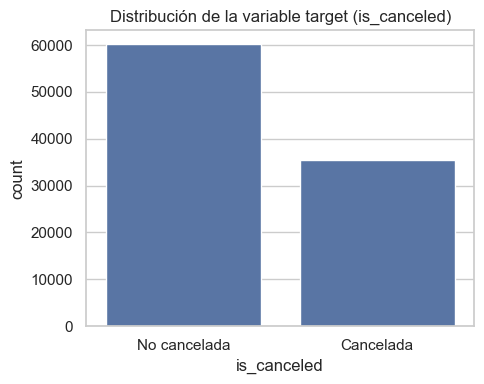

In [5]:
target_counts = df['is_canceled'].value_counts(normalize=True) * 100
print(target_counts)

fig, ax = plt.subplots(figsize=(5,4))
sns.countplot(x='is_canceled', data=df, ax=ax)
ax.set_title('Distribución de la variable target (is_canceled)')
ax.set_xticklabels(['No cancelada', 'Cancelada'])
plt.tight_layout()
plt.savefig(f'{IMG_DIR}/target_balance.png', dpi=100)
plt.show()

**Conclusión:** desbalanceo moderado — 62.96% no canceladas vs. 37.04% canceladas. No es extremo, pero conviene usar `class_weight='balanced'` o estratificar bien la validación cruzada, y evitar Accuracy como métrica única (mejor F1 / Recall / ROC-AUC).

## Paso 4: Relación features vs. target

C:\Users\nilco\AppData\Local\Temp\ipykernel_20232\865473220.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No cancelada', 'Cancelada'])


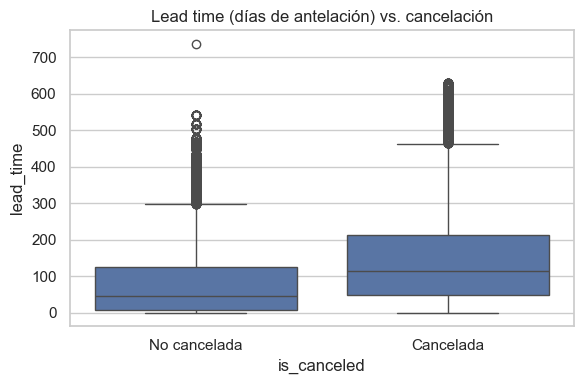

is_canceled
0     45.0
1    113.0
Name: lead_time, dtype: float64

In [6]:
fig, ax = plt.subplots(figsize=(6,4))
sns.boxplot(x='is_canceled', y='lead_time', data=df, ax=ax)
ax.set_title('Lead time (días de antelación) vs. cancelación')
ax.set_xticklabels(['No cancelada', 'Cancelada'])
plt.tight_layout()
plt.savefig(f'{IMG_DIR}/lead_time_vs_target.png', dpi=100)
plt.show()

df.groupby('is_canceled')['lead_time'].median()

deposit_type
Non Refund    0.993770
No Deposit    0.283342
Refundable    0.225564
Name: is_canceled, dtype: float64


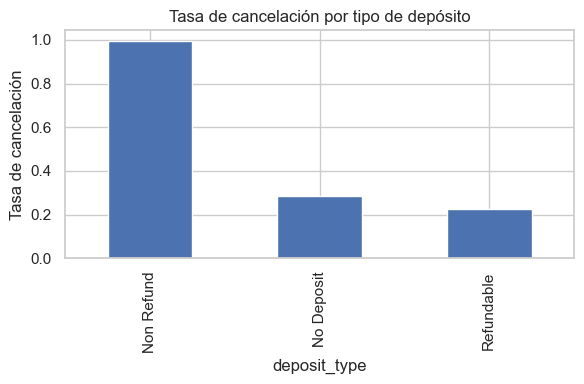

In [7]:
rate_deposit = df.groupby('deposit_type')['is_canceled'].mean().sort_values(ascending=False)
print(rate_deposit)

fig, ax = plt.subplots(figsize=(6,4))
rate_deposit.plot(kind='bar', ax=ax)
ax.set_ylabel('Tasa de cancelación')
ax.set_title('Tasa de cancelación por tipo de depósito')
plt.tight_layout()
plt.savefig(f'{IMG_DIR}/deposit_type_vs_target.png', dpi=100)
plt.show()

**Hallazgo relevante:** las reservas con `deposit_type = 'Non Refund'` tienen una tasa de cancelación mucho más alta que `No Deposit` o `Refundable`. Contraintuitivo a priori (uno esperaría que pagar un depósito no reembolsable desincentive cancelar), pero es un patrón conocido en este dataset y una feature muy predictiva.

market_segment
Undefined        1.000000
Groups           0.610609
Online TA        0.366280
Offline TA/TO    0.342747
Aviation         0.223958
Corporate        0.187263
Direct           0.153754
Complementary    0.135987
Name: is_canceled, dtype: float64


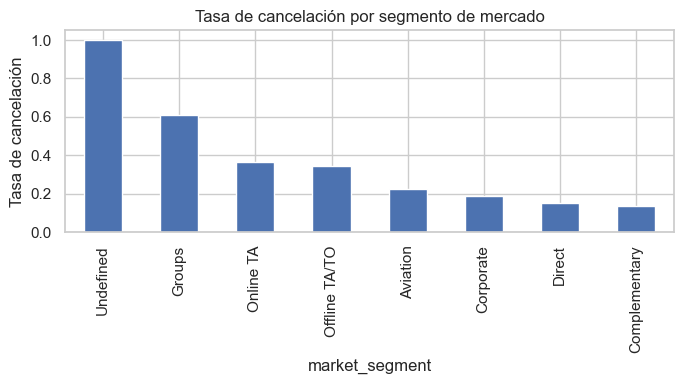

In [8]:
rate_segment = df.groupby('market_segment')['is_canceled'].mean().sort_values(ascending=False)
print(rate_segment)

fig, ax = plt.subplots(figsize=(7,4))
rate_segment.plot(kind='bar', ax=ax)
ax.set_ylabel('Tasa de cancelación')
ax.set_title('Tasa de cancelación por segmento de mercado')
plt.tight_layout()
plt.savefig(f'{IMG_DIR}/market_segment_vs_target.png', dpi=100)
plt.show()

C:\Users\nilco\AppData\Local\Temp\ipykernel_20232\3660365193.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No cancelada', 'Cancelada'])


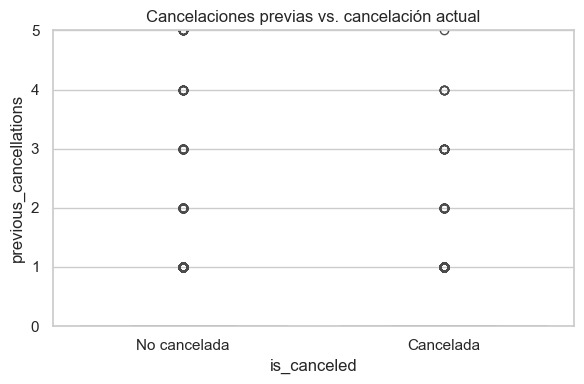

In [9]:
fig, ax = plt.subplots(figsize=(6,4))
sns.boxplot(x='is_canceled', y='previous_cancellations', data=df, ax=ax)
ax.set_title('Cancelaciones previas vs. cancelación actual')
ax.set_xticklabels(['No cancelada', 'Cancelada'])
ax.set_ylim(0, 5)
plt.tight_layout()
plt.savefig(f'{IMG_DIR}/previous_cancellations_vs_target.png', dpi=100)
plt.show()

## Paso 5: Correlaciones entre features numéricas

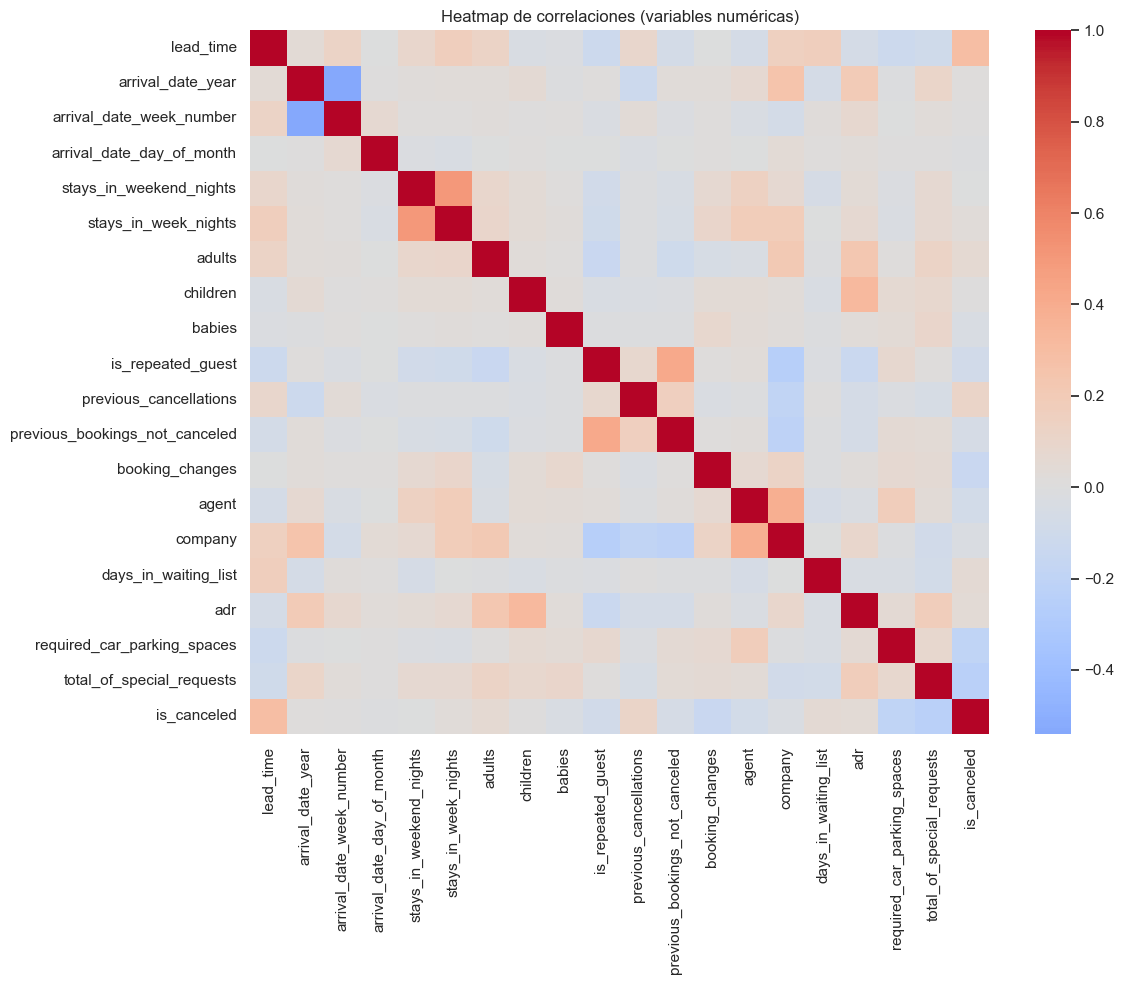

is_canceled                       1.000000
lead_time                         0.293034
previous_cancellations            0.111525
adults                            0.057953
days_in_waiting_list              0.053600
adr                               0.046147
stays_in_week_nights              0.025650
arrival_date_year                 0.017537
arrival_date_week_number          0.007270
children                          0.005648
stays_in_weekend_nights           0.000977
arrival_date_day_of_month        -0.006720
company                          -0.023931
babies                           -0.030659
previous_bookings_not_canceled   -0.057203
agent                            -0.079114
is_repeated_guest                -0.086247
booking_changes                  -0.141886
required_car_parking_spaces      -0.194639
total_of_special_requests        -0.236955
Name: is_canceled, dtype: float64

In [10]:
num_cols = df.select_dtypes(include=[np.number]).columns.drop('is_canceled')
corr = df[num_cols.tolist() + ['is_canceled']].corr()

fig, ax = plt.subplots(figsize=(12,10))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False, ax=ax)
ax.set_title('Heatmap de correlaciones (variables numéricas)')
plt.tight_layout()
plt.savefig(f'{IMG_DIR}/correlation_heatmap.png', dpi=100)
plt.show()

corr['is_canceled'].sort_values(ascending=False)

**Conclusión:** `lead_time` y `previous_cancellations` son las variables numéricas más correlacionadas (positivamente) con `is_canceled`. No se observa multicolinealidad severa entre features (aparte de correlaciones esperables como `stays_in_weekend_nights`/`stays_in_week_nights` con `adr`).

## Paso 6: Detección de outliers

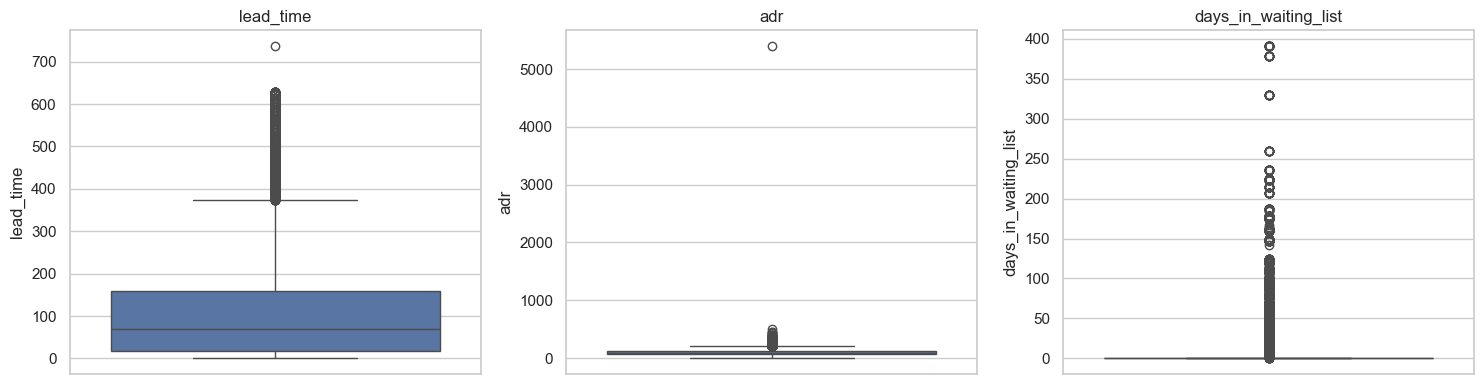

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
sns.boxplot(y=df['lead_time'], ax=axes[0]); axes[0].set_title('lead_time')
sns.boxplot(y=df['adr'], ax=axes[1]); axes[1].set_title('adr')
sns.boxplot(y=df['days_in_waiting_list'], ax=axes[2]); axes[2].set_title('days_in_waiting_list')
plt.tight_layout()
plt.savefig(f'{IMG_DIR}/outliers_boxplots.png', dpi=100)
plt.show()

In [12]:
def iqr_outlier_pct(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    return ((series < lower) | (series > upper)).mean() * 100

for col in ['lead_time', 'adr', 'days_in_waiting_list']:
    print(f'{col}: {iqr_outlier_pct(df[col]):.2f}% outliers (IQR)')

lead_time: 2.50% outliers (IQR)
adr: 3.14% outliers (IQR)
days_in_waiting_list: 3.11% outliers (IQR)


In [13]:
print('adr max:', df['adr'].max())
print('adr min:', df['adr'].min())
df[df['adr'] < 0][['adr','hotel','is_canceled']]

adr max: 5400.0
adr min: -6.38


,adr,hotel,is_canceled
60681,-6.38,Resort Hotel,0


**Conclusión outliers:**
- `adr` (precio medio diario) tiene un valor negativo anómalo y un extremo muy alto — candidatos a revisar/capear en preprocessing (posible error de registro).
- `lead_time` y `days_in_waiting_list` tienen cola larga a la derecha (right-skewed) pero son valores de negocio plausibles (reservas con mucha antelación) — no se recomienda eliminarlos, sí valorar transformación log para modelos lineales.


## Resumen de hallazgos para preprocessing

1. **Eliminar `reservation_status` y `reservation_status_date`** — data leakage directo del target.
2. **Missings de `company`/`agent`** son informativos ("sin agencia"), no imputar con estadísticos, tratar como categoría propia o indicador binario.
3. **`country`** (0.4%) y **`children`** (0.004%) — imputación simple (moda / mediana).
4. **Features más predictivas identificadas:** `lead_time`, `deposit_type`, `market_segment`, `previous_cancellations`, `country`.
5. **`adr`**: valor negativo y outliers extremos a revisar/capear.
6. **Target desbalanceado (63/37)** — usar `class_weight='balanced'`, `stratify` en CV, evitar Accuracy como métrica única.